# Simple Parameter Sensitivity

This notebook changes one behavioral or demand parameter group at a time and plots one chosen relative metric.

Metrics available:

- `utilization`: served slots / total slots
- `avg_wait`: average booking delay in days among booked patients
- `service_rate`: served patients / arrivals

There are no absolute served-patient totals here because the number served scales with `measure_days`. Rates and averages are comparable when the simulation length changes.

For balking and no-show threshold rules, the notebook compares class 1 against class 2 directly:

- class 1 step size vs class 2 step size
- class 1 threshold vs class 2 threshold

For arrival-mix scenarios, total arrival rate is `lambda_total`, class 1 gets `p * lambda_total`, and class 2 gets `(1 - p) * lambda_total`.

In [39]:
from pathlib import Path
from dataclasses import replace
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config_loader import load_config
from engine import ClinicAppointmentSimulation
from model import ThresholdRule

plt.style.use("default")

In [40]:
base_config = load_config("configs/baseline.yaml")

# Change this to "avg_wait" or "service_rate" if desired.
METRIC = "service_rate"

STEPS = np.linspace(0, 1, 12)                  # step size values: 0.0, 0.2, ..., 1.0
THRESHOLDS = range(base_config.horizon_days) # step moment in days
CANCEL_PROBS = np.linspace(0, 0.30, 14)        # cancellation probabilities

BASE_LAMBDA_TOTAL = sum(params.lambda_per_day for params in base_config.classes.values())
ARRIVAL_RATE_MULTIPLIERS = np.linspace(0.5, 1.5, 12)
CLASS_1_SHARES = np.linspace(0.1, 0.9, 18)

SEED = 123

## Metric Code

In [41]:
def run_metrics(config, seed=SEED):
    config = replace(config, seed=seed)
    results = ClinicAppointmentSimulation(config).run()

    booked = sum(m.booked for m in results.class_metrics.values())
    served = sum(m.served for m in results.class_metrics.values())
    booking_delay = sum(m.total_booking_delay for m in results.class_metrics.values())
    arrivals = sum(m.arrivals for m in results.class_metrics.values())

    return {
        "utilization": results.slot_metrics.served_slots / results.total_slots,
        "avg_wait": booking_delay / booked if booked else 0,
        "service_rate": served / arrivals if arrivals else 0,
    }

base_metrics = pd.DataFrame([run_metrics(base_config)])
display(base_metrics)

,utilization,avg_wait,service_rate
0,1.0,7.021499,0.34741


## Small Helpers To Change Parameters

In [42]:
def make_step_rule(old_rule, threshold=None, step=None):
    threshold = old_rule.threshold if threshold is None else int(threshold)
    low = old_rule.low
    step = old_rule.high - old_rule.low if step is None else float(step)
    return ThresholdRule(threshold=threshold, low=low, high=min(low + step, 1.0))


def update_classes(config, changes):
    classes = {}
    for class_id, params in config.classes.items():
        classes[class_id] = replace(params, **changes.get(class_id, {}))
    return replace(config, classes=classes)


def set_balking(config, class_steps=None, class_thresholds=None):
    class_steps = class_steps or {}
    class_thresholds = class_thresholds or {}
    changes = {}
    for class_id, params in config.classes.items():
        changes[class_id] = {
            "balk_prob": make_step_rule(
                params.balk_prob,
                threshold=class_thresholds.get(class_id),
                step=class_steps.get(class_id),
            )
        }
    return update_classes(config, changes)


def set_no_show(config, class_steps=None, class_thresholds=None):
    class_steps = class_steps or {}
    class_thresholds = class_thresholds or {}
    changes = {}
    for class_id, params in config.classes.items():
        changes[class_id] = {
            "no_show_prob": make_step_rule(
                params.no_show_prob,
                threshold=class_thresholds.get(class_id),
                step=class_steps.get(class_id),
            )
        }
    return update_classes(config, changes)


def set_cancellation(config, class_probs):
    changes = {class_id: {"cancel_prob": prob} for class_id, prob in class_probs.items()}
    return update_classes(config, changes)


def set_arrival_mix(config, lambda_total, class_1_share):
    class_1_share = float(class_1_share)
    lambda_total = float(lambda_total)
    return update_classes(
        config,
        {
            1: {"lambda_per_day": class_1_share * lambda_total},
            2: {"lambda_per_day": (1 - class_1_share) * lambda_total},
        },
    )


def set_arrival_multiplier(config, multiplier):
    lambda_total = BASE_LAMBDA_TOTAL * float(multiplier)
    base_class_1_share = config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL
    return set_arrival_mix(config, lambda_total, base_class_1_share)

In [43]:
def heatmap(df, x, y, value=METRIC, title=None):
    table = df.pivot(index=y, columns=x, values=value).sort_index().sort_index(axis=1)

    fig, ax = plt.subplots(figsize=(7, 5))
    image = ax.imshow(table.values, origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(title or value)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_xticks(range(len(table.columns)))
    ax.set_xticklabels([f"{v:.2f}" if isinstance(v, float) else v for v in table.columns])
    ax.set_yticks(range(len(table.index)))
    ax.set_yticklabels([f"{v:.2f}" if isinstance(v, float) else v for v in table.index])
    fig.colorbar(image, ax=ax, label=value)
    plt.show()

    return table

## 1. Balking Step Size By Class

Everything stays at baseline except the balking step size for class 1 and class 2.

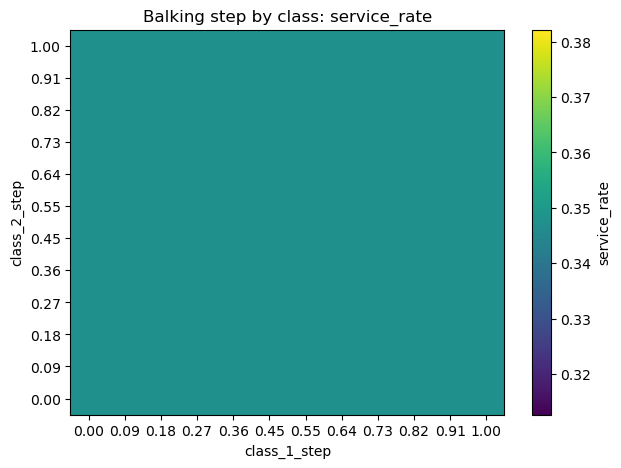

class_1_step,0.000000,0.090909,0.181818,0.272727,0.363636,0.454545,0.545455,0.636364,0.727273,0.818182,0.909091,1.000000
class_2_step,,,,,,,,,,,,
0.000000,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.090909,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.181818,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.272727,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.363636,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.454545,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.545455,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.636364,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.727273,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741


In [44]:
rows = []
for class_1_step, class_2_step in product(STEPS, STEPS):
    config = set_balking(base_config, class_steps={1: class_1_step, 2: class_2_step})
    rows.append({
        "class_1_step": class_1_step,
        "class_2_step": class_2_step,
        **run_metrics(config),
    })

balk_class_df = pd.DataFrame(rows)
heatmap(balk_class_df, "class_1_step", "class_2_step", title=f"Balking step by class: {METRIC}")

## 2. Balking Threshold By Class

Everything stays at baseline except the balking threshold for class 1 and class 2. Step sizes stay fixed at baseline.

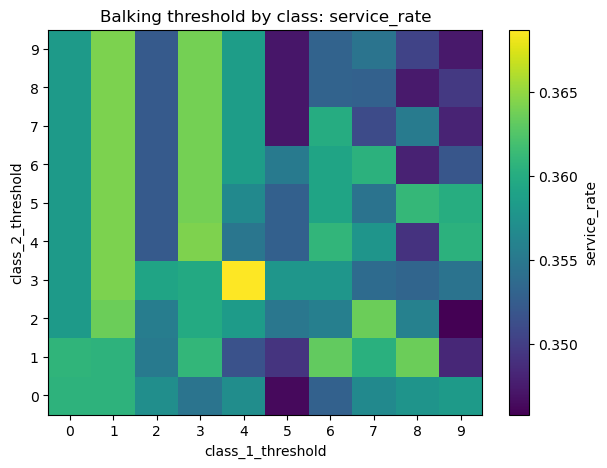

class_1_threshold,0,1,2,3,4,5,6,7,8,9
class_2_threshold,,,,,,,,,,
0,0.360631,0.360631,0.357116,0.354624,0.357063,0.346356,0.352930,0.356691,0.357652,0.358324
1,0.360819,0.360631,0.355239,0.360986,0.351598,0.349218,0.363189,0.360338,0.363517,0.348343
2,0.358304,0.363585,0.355502,0.359775,0.358382,0.354886,0.355695,0.363585,0.355888,0.345818
3,0.358304,0.364222,0.359200,0.359707,0.368694,0.357873,0.357846,0.353815,0.353310,0.354512
4,0.358304,0.364222,0.352300,0.364274,0.354779,0.352801,0.360898,0.357714,0.349201,0.360529
5,0.358304,0.364222,0.352300,0.363894,0.356678,0.352801,0.359165,0.354517,0.361064,0.360083
6,0.358304,0.364222,0.352300,0.363894,0.358547,0.355178,0.359165,0.360480,0.348024,0.351923
7,0.358304,0.364222,0.352300,0.363894,0.358547,0.347227,0.360023,0.351072,0.355300,0.348113
8,0.358304,0.364222,0.352300,0.363894,0.358547,0.347227,0.353104,0.352941,0.347448,0.349644


In [45]:
rows = []
for class_1_threshold, class_2_threshold in product(THRESHOLDS, THRESHOLDS):
    config = set_balking(
        base_config,
        class_thresholds={1: class_1_threshold, 2: class_2_threshold},
    )
    rows.append({
        "class_1_threshold": class_1_threshold,
        "class_2_threshold": class_2_threshold,
        **run_metrics(config),
    })

balk_threshold_df = pd.DataFrame(rows)
heatmap(
    balk_threshold_df,
    "class_1_threshold",
    "class_2_threshold",
    title=f"Balking threshold by class: {METRIC}",
)

## 3. No-Show Step Size By Class

Everything stays at baseline except the no-show step size for class 1 and class 2. Thresholds stay fixed at baseline.

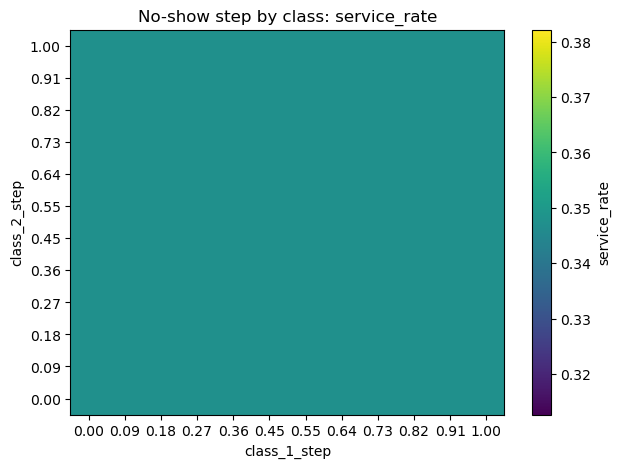

class_1_step,0.000000,0.090909,0.181818,0.272727,0.363636,0.454545,0.545455,0.636364,0.727273,0.818182,0.909091,1.000000
class_2_step,,,,,,,,,,,,
0.000000,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.090909,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.181818,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.272727,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.363636,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.454545,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.545455,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.636364,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741
0.727273,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741,0.34741


In [46]:
rows = []
for class_1_step, class_2_step in product(STEPS, STEPS):
    config = set_no_show(base_config, class_steps={1: class_1_step, 2: class_2_step})
    rows.append({
        "class_1_step": class_1_step,
        "class_2_step": class_2_step,
        **run_metrics(config),
    })

no_show_step_df = pd.DataFrame(rows)
heatmap(
    no_show_step_df,
    "class_1_step",
    "class_2_step",
    title=f"No-show step by class: {METRIC}",
)

## 4. No-Show Threshold By Class

Everything stays at baseline except the no-show threshold for class 1 and class 2. Step sizes stay fixed at baseline.

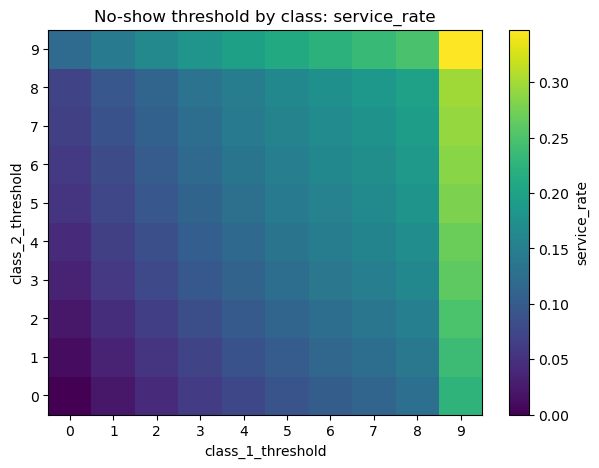

class_1_threshold,0,1,2,3,4,5,6,7,8,9
class_2_threshold,,,,,,,,,,
0,0.000000,0.022559,0.042050,0.060097,0.075979,0.090236,0.102870,0.113517,0.127414,0.226493
1,0.011370,0.033929,0.053420,0.071467,0.087349,0.101606,0.114239,0.124887,0.138784,0.237863
2,0.022920,0.045479,0.064970,0.083018,0.098899,0.113156,0.125790,0.136437,0.150334,0.249413
3,0.035012,0.057571,0.077062,0.095109,0.110991,0.125248,0.137881,0.148529,0.162426,0.261505
4,0.043313,0.065873,0.085364,0.103411,0.119293,0.133550,0.146183,0.156831,0.170727,0.269807
5,0.051796,0.074355,0.093846,0.111893,0.127775,0.142032,0.154665,0.165313,0.179210,0.278289
6,0.058654,0.081213,0.100704,0.118751,0.134633,0.148890,0.161523,0.172171,0.186067,0.285147
7,0.065331,0.087890,0.107381,0.125429,0.141310,0.155568,0.168201,0.178849,0.192745,0.291825
8,0.071828,0.094387,0.113878,0.131926,0.147807,0.162065,0.174698,0.185346,0.199242,0.298322


In [47]:
rows = []
for class_1_threshold, class_2_threshold in product(THRESHOLDS, THRESHOLDS):
    config = set_no_show(
        base_config,
        class_thresholds={1: class_1_threshold, 2: class_2_threshold},
    )
    rows.append({
        "class_1_threshold": class_1_threshold,
        "class_2_threshold": class_2_threshold,
        **run_metrics(config),
    })

no_show_threshold_df = pd.DataFrame(rows)
heatmap(
    no_show_threshold_df,
    "class_1_threshold",
    "class_2_threshold",
    title=f"No-show threshold by class: {METRIC}",
)

## 5. Cancellation Probability By Class

Cancellation has no threshold in this model, so this varies the daily cancellation probability for each class.

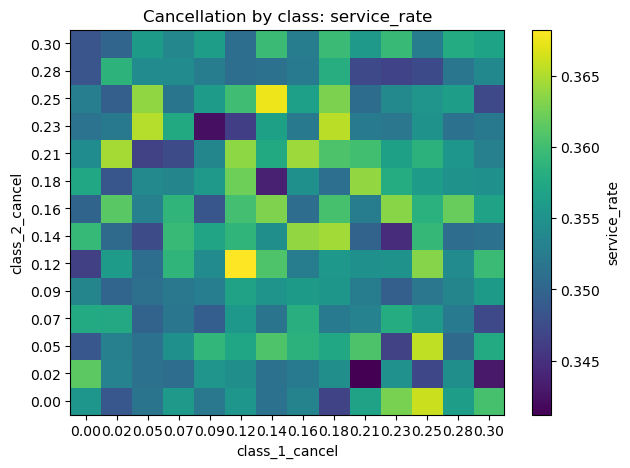

class_1_cancel,0.000000,0.023077,0.046154,0.069231,0.092308,0.115385,0.138462,0.161538,0.184615,0.207692,0.230769,0.253846,0.276923,0.300000
class_2_cancel,,,,,,,,,,,,,,
0.000000,0.355424,0.348545,0.351614,0.355737,0.352053,0.355383,0.351331,0.353269,0.346757,0.356809,0.362788,0.366070,0.356379,0.360359
0.023077,0.361414,0.353180,0.351346,0.350916,0.355349,0.354713,0.351381,0.352454,0.354601,0.341202,0.354887,0.347061,0.354644,0.343022
0.046154,0.348559,0.352995,0.351346,0.354821,0.359114,0.357103,0.360757,0.358603,0.357475,0.360745,0.346468,0.365624,0.350597,0.357709
0.069231,0.357754,0.357518,0.349845,0.351835,0.349338,0.355651,0.351600,0.358117,0.352323,0.353148,0.357981,0.355857,0.352239,0.347217
0.092308,0.353474,0.350073,0.351173,0.352071,0.352821,0.356823,0.355217,0.355932,0.355531,0.352639,0.349380,0.351879,0.353539,0.355948
0.115385,0.346327,0.356167,0.350996,0.358936,0.354224,0.368259,0.360792,0.352672,0.355662,0.354797,0.355035,0.363326,0.354236,0.359685
0.138462,0.359281,0.350590,0.347493,0.359419,0.357050,0.358950,0.354626,0.363913,0.364534,0.349818,0.344615,0.359250,0.350842,0.351421
0.161538,0.349945,0.361300,0.352952,0.358955,0.348463,0.360150,0.363003,0.350839,0.360367,0.352605,0.363415,0.358522,0.361930,0.356785
0.184615,0.357342,0.348446,0.353937,0.353550,0.355684,0.362261,0.343638,0.354785,0.351058,0.363860,0.357926,0.356175,0.355064,0.354749


In [48]:
rows = []
for class_1_cancel, class_2_cancel in product(CANCEL_PROBS, CANCEL_PROBS):
    config = set_cancellation(base_config, {1: class_1_cancel, 2: class_2_cancel})
    rows.append({
        "class_1_cancel": class_1_cancel,
        "class_2_cancel": class_2_cancel,
        **run_metrics(config),
    })

cancel_df = pd.DataFrame(rows)
heatmap(cancel_df, "class_1_cancel", "class_2_cancel", title=f"Cancellation by class: {METRIC}")

## 6. Total Arrival Rate And Class Mix

This varies demand pressure and the class mix together. For each grid point:

- `lambda_total = multiplier * baseline lambda_total`
- `lambda_1 = p * lambda_total`
- `lambda_2 = (1 - p) * lambda_total`

All behavioral rules stay fixed at baseline.

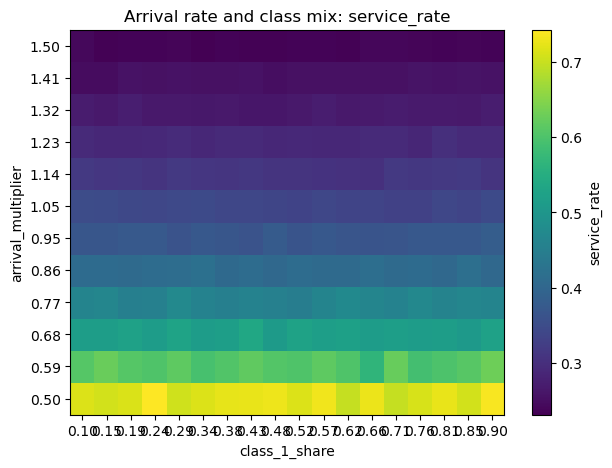

class_1_share,0.100000,0.147059,0.194118,0.241176,0.288235,0.335294,0.382353,0.429412,0.476471,0.523529,0.570588,0.617647,0.664706,0.711765,0.758824,0.805882,0.852941,0.900000
arrival_multiplier,,,,,,,,,,,,,,,,,,
0.500000,0.715867,0.706840,0.713121,0.742442,0.705305,0.715875,0.724254,0.725446,0.729811,0.715968,0.731332,0.697781,0.727374,0.698304,0.711426,0.724812,0.708272,0.737362
0.590909,0.606929,0.625159,0.607635,0.602592,0.615141,0.593252,0.604688,0.617268,0.605438,0.602710,0.615021,0.601067,0.565038,0.623951,0.589425,0.600623,0.610480,0.630684
0.681818,0.516653,0.516155,0.523123,0.513225,0.527104,0.513506,0.518076,0.535937,0.510884,0.526632,0.518926,0.521751,0.513284,0.518219,0.513658,0.515764,0.508425,0.523098
0.772727,0.462679,0.467177,0.452534,0.455087,0.471661,0.458403,0.452741,0.458764,0.454352,0.447929,0.462963,0.473749,0.465195,0.459115,0.471140,0.459889,0.466683,0.462470
0.863636,0.410377,0.409422,0.409314,0.411714,0.413703,0.419594,0.406310,0.412435,0.403915,0.411424,0.408829,0.407850,0.417316,0.408077,0.409567,0.405193,0.417735,0.404797
0.954545,0.367732,0.368381,0.374240,0.374803,0.363395,0.373391,0.367681,0.362637,0.377840,0.364787,0.372802,0.366584,0.363758,0.367355,0.372075,0.372183,0.373076,0.381862
1.045455,0.350386,0.348133,0.342020,0.339583,0.343975,0.345980,0.340546,0.340403,0.338041,0.333739,0.339883,0.336380,0.335732,0.330102,0.331494,0.341216,0.337458,0.345786
1.136364,0.317532,0.312756,0.315148,0.308764,0.316694,0.313306,0.310850,0.314132,0.309059,0.309029,0.305715,0.305372,0.303064,0.316824,0.313946,0.316093,0.318204,0.308039
1.227273,0.293156,0.288268,0.287996,0.291453,0.295294,0.287904,0.292646,0.292294,0.289438,0.291484,0.289636,0.289565,0.292694,0.291995,0.286463,0.299798,0.292787,0.291896


In [49]:
rows = []
for multiplier, class_1_share in product(ARRIVAL_RATE_MULTIPLIERS, CLASS_1_SHARES):
    lambda_total = BASE_LAMBDA_TOTAL * multiplier
    config = set_arrival_mix(base_config, lambda_total, class_1_share)
    rows.append({
        "arrival_multiplier": multiplier,
        "class_1_share": class_1_share,
        "lambda_total": lambda_total,
        "lambda_1": class_1_share * lambda_total,
        "lambda_2": (1 - class_1_share) * lambda_total,
        **run_metrics(config),
    })

demand_mix_df = pd.DataFrame(rows)
heatmap(
    demand_mix_df,
    "class_1_share",
    "arrival_multiplier",
    title=f"Arrival rate and class mix: {METRIC}",
)

## 7. Named Demand Scenarios

These are a few readable scenarios around the baseline. They are useful when you want a compact table rather than a full grid.

,scenario,arrival_multiplier,class_1_share,lambda_1,lambda_2,utilization,avg_wait,service_rate
1,low demand,0.75,0.666667,45.000,22.500,1.0,6.960956,0.472257
3,class 1 heavy,1.00,0.750000,67.500,22.500,1.0,6.988963,0.351968
4,class 2 heavy,1.00,0.250000,22.500,67.500,1.0,7.049956,0.349736
0,baseline,1.00,0.666667,60.000,30.000,1.0,7.021499,0.347410
2,high demand,1.25,0.666667,75.000,37.500,1.0,6.971346,0.285841
5,"high demand, class 1 heavy",1.25,0.750000,84.375,28.125,1.0,6.970605,0.285124
6,"high demand, class 2 heavy",1.25,0.250000,28.125,84.375,1.0,7.041175,0.283996


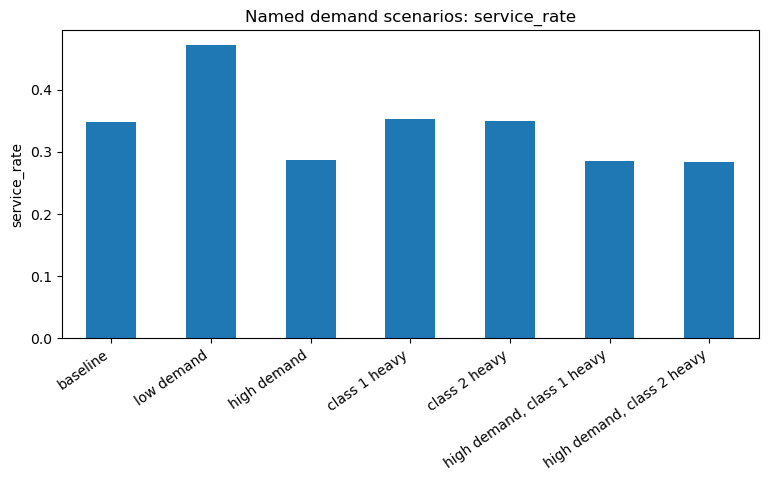

In [50]:
named_scenarios = [
    ("baseline", 1.00, base_config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL),
    ("low demand", 0.75, base_config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL),
    ("high demand", 1.25, base_config.classes[1].lambda_per_day / BASE_LAMBDA_TOTAL),
    ("class 1 heavy", 1.00, 0.75),
    ("class 2 heavy", 1.00, 0.25),
    ("high demand, class 1 heavy", 1.25, 0.75),
    ("high demand, class 2 heavy", 1.25, 0.25),
]

rows = []
for name, multiplier, class_1_share in named_scenarios:
    lambda_total = BASE_LAMBDA_TOTAL * multiplier
    config = set_arrival_mix(base_config, lambda_total, class_1_share)
    rows.append({
        "scenario": name,
        "arrival_multiplier": multiplier,
        "class_1_share": class_1_share,
        "lambda_1": class_1_share * lambda_total,
        "lambda_2": (1 - class_1_share) * lambda_total,
        **run_metrics(config),
    })

named_demand_df = pd.DataFrame(rows)
display(named_demand_df.sort_values(METRIC, ascending=(METRIC == "avg_wait")))

fig, ax = plt.subplots(figsize=(9, 4))
named_demand_df.plot(kind="bar", x="scenario", y=METRIC, ax=ax, legend=False)
ax.set_title(f"Named demand scenarios: {METRIC}")
ax.set_xlabel("")
ax.set_ylabel(METRIC)
plt.xticks(rotation=35, ha="right")
plt.show()

## Best Tested Settings

In [51]:
def best_rows(df, n=5):
    # For avg_wait lower is better. For utilization and service_rate higher is better.
    ascending = METRIC == "avg_wait"
    return df.sort_values(METRIC, ascending=ascending).head(n)

print("Balking step sweep")
display(best_rows(balk_class_df))

print("Balking threshold sweep")
display(best_rows(balk_threshold_df))

print("No-show step sweep")
display(best_rows(no_show_step_df))

print("No-show threshold sweep")
display(best_rows(no_show_threshold_df))

print("Cancellation sweep")
display(best_rows(cancel_df))

print("Arrival rate and class-mix sweep")
display(best_rows(demand_mix_df))

print("Named demand scenarios")
display(best_rows(named_demand_df))

Balking step sweep


,class_1_step,class_2_step,utilization,avg_wait,service_rate
0,0.000000,0.000000,1.0,7.021499,0.34741
1,0.000000,0.090909,1.0,7.021499,0.34741
92,0.636364,0.727273,1.0,7.021499,0.34741
93,0.636364,0.818182,1.0,7.021499,0.34741
94,0.636364,0.909091,1.0,7.021499,0.34741


Balking threshold sweep


,class_1_threshold,class_2_threshold,utilization,avg_wait,service_rate
43,4,3,1.0,3.573517,0.368694
34,3,4,1.0,3.332925,0.364274
19,1,9,1.0,1.774146,0.364222
13,1,3,1.0,1.774146,0.364222
18,1,8,1.0,1.774146,0.364222


No-show step sweep


...

,class_1_cancel,class_2_cancel,utilization,avg_wait,service_rate
75,0.115385,0.115385,1.0,6.860522,0.368259
95,0.138462,0.253846,1.0,6.417316,0.367523
154,0.253846,0.000000,1.0,6.939502,0.366070
156,0.253846,0.046154,1.0,6.597145,0.365624
122,0.184615,0.230769,1.0,6.119770,0.365469


Arrival rate and class-mix sweep


,arrival_multiplier,class_1_share,lambda_total,lambda_1,lambda_2,utilization,avg_wait,service_rate
3,0.5,0.241176,45.0,10.852941,34.147059,1.0,4.101416,0.742442
17,0.5,0.900000,45.0,40.500000,4.500000,1.0,4.109844,0.737362
10,0.5,0.570588,45.0,25.676471,19.323529,1.0,3.941839,0.731332
8,0.5,0.476471,45.0,21.441176,23.558824,1.0,4.119245,0.729811
12,0.5,0.664706,45.0,29.911765,15.088235,1.0,4.200372,0.727374


Named demand scenarios


,scenario,arrival_multiplier,class_1_share,lambda_1,lambda_2,utilization,avg_wait,service_rate
1,low demand,0.75,0.666667,45.0,22.5,1.0,6.960956,0.472257
3,class 1 heavy,1.00,0.750000,67.5,22.5,1.0,6.988963,0.351968
4,class 2 heavy,1.00,0.250000,22.5,67.5,1.0,7.049956,0.349736
0,baseline,1.00,0.666667,60.0,30.0,1.0,7.021499,0.347410
2,high demand,1.25,0.666667,75.0,37.5,1.0,6.971346,0.285841
